In [ ]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

filename = next(iter(uploaded))
df = pd.read_csv(filename)

print("✅ Dataset loaded successfully!")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

display(df.head())

Saving Resume.csv to Resume.csv
✅ Dataset loaded successfully!
Shape: (2856, 1)
Columns: ['resume_id,category,resume_text,skills_list,experience_years']


,"resume_id,category,resume_text,skills_list,experience_years"
0,"1,HR,hr administrator marketing associate hr a..."
1,"2,HR,hr specialist us hr operations summary ve..."
2,"3,HR,hr director summary over years experience..."
3,"4,HR,hr specialist summary dedicated driven an..."
4,"5,HR,hr manager skill highlights hr skills hr ..."


In [ ]:
import pandas as pd

df = pd.read_csv("Resume.csv", encoding="utf-8-sig", engine="python", sep=",", on_bad_lines="skip")

if len(df.columns) == 1:
    df = pd.read_csv("Resume.csv", encoding="latin1", engine="python", sep=",", on_bad_lines="skip")

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
display(df.head())

Dataset loaded successfully!
Shape: (2856, 5)
Columns: ['ï»¿"resume_id', 'category', 'resume_text', 'skills_list', 'experience_years"']


,"ï»¿""resume_id",category,resume_text,skills_list,"experience_years"""
0,"1,HR,hr administrator marketing associate hr a...",NaN,NaN,NaN,NaN
1,"2,HR,hr specialist us hr operations summary ve...",NaN,NaN,NaN,NaN
2,"3,HR,hr director summary over years experience...",NaN,NaN,NaN,NaN
3,"4,HR,hr specialist summary dedicated driven an...",NaN,NaN,NaN,NaN
4,"5,HR,hr manager skill highlights hr skills hr ...",NaN,NaN,NaN,NaN


In [ ]:
import pandas as pd
import csv

rows = []

with open("Resume.csv", "r", encoding="utf-8-sig") as f:
    for line in f:
        line = line.strip()

        if not line:
            continue

        if line.startswith('"') and line.endswith('"'):
            line = line[1:-1]

        parts = line.split(",", 2)

        if len(parts) >= 3:
            resume_id = parts[0]
            category = parts[1]
            remaining = parts[2]

            last_comma = remaining.rfind(",")

            if last_comma != -1:
                experience_years = remaining[last_comma + 1:]
                middle = remaining[:last_comma]

                skill_start = middle.rfind("[")

                if skill_start != -1:
                    resume_text = middle[:skill_start].rstrip(",")
                    skills_list = middle[skill_start:]
                else:
                    resume_text = middle
                    skills_list = ""

                rows.append([
                    resume_id,
                    category,
                    resume_text,
                    skills_list,
                    experience_years
                ])

df = pd.DataFrame(
    rows,
    columns=[
        "resume_id",
        "category",
        "resume_text",
        "skills_list",
        "experience_years"
    ]
)

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

display(df.head())

Dataset loaded successfully!
Shape: (2835, 5)
Columns: ['resume_id', 'category', 'resume_text', 'skills_list', 'experience_years']


,resume_id,category,resume_text,skills_list,experience_years
0,resume_id,category,"resume_text,skills_list",,experience_years
1,1,HR,hr administrator marketing associate hr admini...,,0.0
2,2,HR,hr specialist us hr operations summary versati...,,0.0
3,3,HR,hr director summary over years experience in r...,,20.0
4,4,HR,hr specialist summary dedicated driven and dyn...,,20.0


In [ ]:
df = df[df["resume_id"] != "resume_id"].copy()

df["resume_id"] = pd.to_numeric(df["resume_id"], errors="coerce")
df["experience_years"] = pd.to_numeric(df["experience_years"], errors="coerce")

df = df.reset_index(drop=True)

print("Shape:", df.shape)
display(df.head())

Shape: (2834, 5)


,resume_id,category,resume_text,skills_list,experience_years
0,1,HR,hr administrator marketing associate hr admini...,,0.0
1,2,HR,hr specialist us hr operations summary versati...,,0.0
2,3,HR,hr director summary over years experience in r...,,20.0
3,4,HR,hr specialist summary dedicated driven and dyn...,,20.0
4,5,HR,hr manager skill highlights hr skills hr depar...,,0.0


In [ ]:
df.isnull().sum()

,0
resume_id,0
category,0
resume_text,0
skills_list,0
experience_years,16


In [4]:
from google.colab import files

uploaded = files.upload()

Saving Resume.csv to Resume.csv


In [5]:
import pandas as pd

rows = []

with open("Resume.csv", "r", encoding="utf-8-sig") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue

        if line.startswith('"') and line.endswith('"'):
            line = line[1:-1]

        parts = line.split(",", 2)

        if len(parts) >= 3:
            resume_id = parts[0]
            category = parts[1]
            remaining = parts[2]
            last_comma = remaining.rfind(",")

            if last_comma != -1:
                experience_years = remaining[last_comma + 1:]
                middle = remaining[:last_comma]
                skill_start = middle.rfind("[")

                if skill_start != -1:
                    resume_text = middle[:skill_start].rstrip(",")
                    skills_list = middle[skill_start:]
                else:
                    resume_text = middle
                    skills_list = ""

                rows.append([
                    resume_id,
                    category,
                    resume_text,
                    skills_list,
                    experience_years
                ])

df = pd.DataFrame(
    rows,
    columns=[
        "resume_id",
        "category",
        "resume_text",
        "skills_list",
        "experience_years"
    ]
)

df = df[df["resume_id"] != "resume_id"].copy()
df["resume_id"] = pd.to_numeric(df["resume_id"], errors="coerce")
df["experience_years"] = pd.to_numeric(
    df["experience_years"], errors="coerce"
).fillna(0)
df = df.reset_index(drop=True)

print("✅ Dataset restored!")
print("Shape:", df.shape)
print(df.isnull().sum())
display(df.head())

✅ Dataset restored!
Shape: (2834, 5)
resume_id           0
category            0
resume_text         0
skills_list         0
experience_years    0
dtype: int64


,resume_id,category,resume_text,skills_list,experience_years
0,1,HR,hr administrator marketing associate hr admini...,,0.0
1,2,HR,hr specialist us hr operations summary versati...,,0.0
2,3,HR,hr director summary over years experience in r...,,20.0
3,4,HR,hr specialist summary dedicated driven and dyn...,,20.0
4,5,HR,hr manager skill highlights hr skills hr depar...,,0.0


In [6]:
import re

df["clean_text"] = (
    df["resume_text"]
    .astype(str)
    .str.lower()
    .apply(lambda x: re.sub(r"[^a-zA-Z0-9\s]", " ", x))
    .apply(lambda x: re.sub(r"\s+", " ", x).strip())
)

print("✅ Resume text cleaned!")
display(df[["resume_text", "clean_text"]].head(3))

✅ Resume text cleaned!


,resume_text,clean_text
0,hr administrator marketing associate hr admini...,hr administrator marketing associate hr admini...
1,hr specialist us hr operations summary versati...,hr specialist us hr operations summary versati...
2,hr director summary over years experience in r...,hr director summary over years experience in r...


In [7]:
df["category"].value_counts()

,count
category,
HR,120
INFORMATION-TECHNOLOGY,120
BUSINESS-DEVELOPMENT,120
ADVOCATE,118
ENGINEERING,118
ACCOUNTANT,118
FITNESS,117
FINANCE,117
CHEF,117


In [8]:
df[["category", "skills_list"]].head(10)

,category,skills_list
0,HR,
1,HR,
2,HR,
3,HR,
4,HR,
5,HR,
6,HR,
7,HR,
8,HR,
9,HR,


In [9]:
df[["category", "resume_text"]].head(5)

,category,resume_text
0,HR,hr administrator marketing associate hr admini...
1,HR,hr specialist us hr operations summary versati...
2,HR,hr director summary over years experience in r...
3,HR,hr specialist summary dedicated driven and dyn...
4,HR,hr manager skill highlights hr skills hr depar...


In [10]:
skills = [
    "python", "java", "sql", "machine learning",
    "deep learning", "tensorflow", "pytorch",
    "pandas", "numpy", "scikit-learn", "nlp"
]

def find_skills(text):
    return [skill for skill in skills if skill in text.lower()]

df["matched_skills"] = df["clean_text"].apply(find_skills)

display(df[["category", "matched_skills"]].head(10))

,category,matched_skills
0,HR,[]
1,HR,[]
2,HR,[]
3,HR,[]
4,HR,[]
5,HR,[]
6,HR,[]
7,HR,[]
8,HR,[]
9,HR,[]


In [11]:
df[df["category"] == "Machine Learning Engineer"][["category", "matched_skills"]].head(10)

,category,matched_skills
2684,Machine Learning Engineer,"[python, machine learning, deep learning, tens..."
2685,Machine Learning Engineer,"[python, machine learning, tensorflow]"
2686,Machine Learning Engineer,"[python, java, machine learning, tensorflow, p..."
2687,Machine Learning Engineer,"[python, machine learning, tensorflow]"
2688,Machine Learning Engineer,"[python, java, machine learning, tensorflow]"
2689,Machine Learning Engineer,"[python, machine learning, deep learning, tens..."
2690,Machine Learning Engineer,"[python, machine learning, tensorflow]"
2691,Machine Learning Engineer,"[python, java, machine learning, tensorflow, p..."
2692,Machine Learning Engineer,"[python, java, machine learning, tensorflow]"
2693,Machine Learning Engineer,"[python, machine learning, deep learning, tens..."


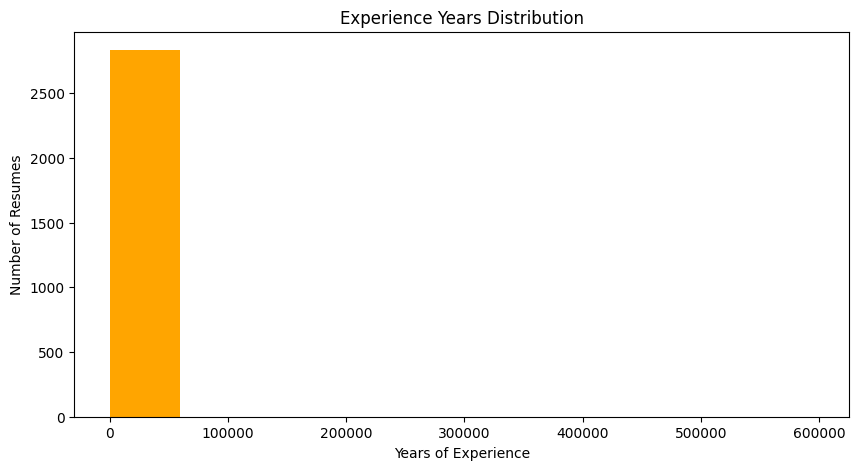

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(df["experience_years"], bins=10, color="orange")
plt.title("Experience Years Distribution")
plt.xlabel("Years of Experience")
plt.ylabel("Number of Resumes")
plt.show()

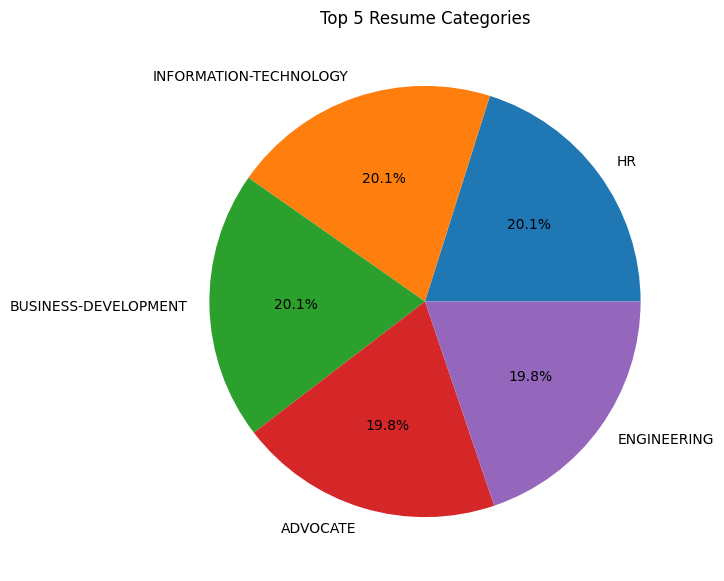

In [16]:
import matplotlib.pyplot as plt

top5 = df["category"].value_counts().head(5)

plt.figure(figsize=(7,7))
plt.pie(
    top5.values,
    labels=top5.index,
    autopct="%1.1f%%"
)
plt.title("Top 5 Resume Categories")
plt.show()

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

job_description = """
Machine Learning Engineer Python machine learning deep learning
SQL pandas numpy scikit-learn tensorflow pytorch NLP data analysis
"""

vectorizer = TfidfVectorizer()
resume_vectors = vectorizer.fit_transform(df["clean_text"])
job_vector = vectorizer.transform([job_description])

df["match_score"] = cosine_similarity(
    resume_vectors,
    job_vector
).flatten() * 100

df["rank"] = df["match_score"].rank(
    ascending=False,
    method="first"
)

top_candidates = df.sort_values("match_score", ascending=False).head(10)

display(
    top_candidates[
        ["resume_id", "category", "experience_years", "match_score", "rank"]
    ]
)

,resume_id,category,experience_years,match_score,rank
2758,2761,Machine Learning Engineer,0.0,42.031332,1.0
2487,2490,Data Science,2.0,41.172369,2.0
2693,2696,Machine Learning Engineer,0.0,39.479330,3.0
2689,2692,Machine Learning Engineer,0.0,39.375668,4.0
2814,2817,Data Scientist,0.0,38.575001,5.0
2756,2759,Machine Learning Engineer,0.0,37.228667,6.0
2488,2491,Data Science,1.0,36.791399,7.0
2759,2762,Machine Learning Engineer,0.0,36.542094,8.0
2686,2689,Machine Learning Engineer,0.0,36.405590,9.0
2691,2694,Machine Learning Engineer,0.0,36.254614,10.0


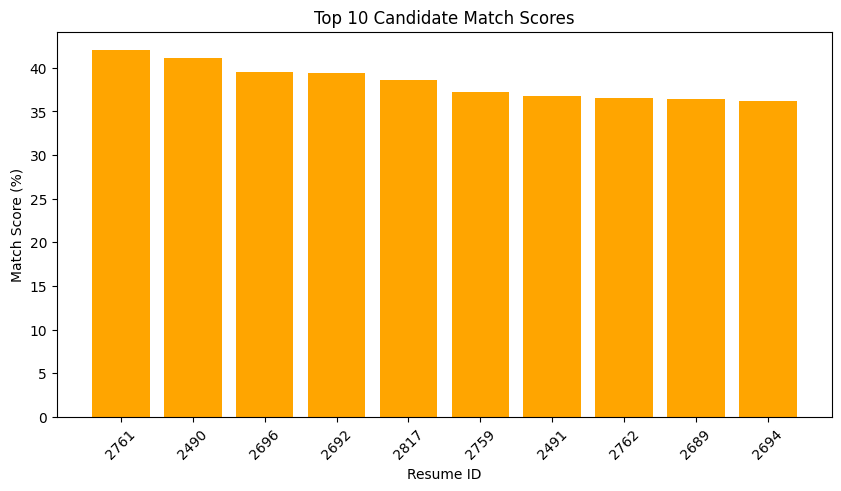

In [18]:
import matplotlib.pyplot as plt

top10 = df.sort_values("match_score", ascending=False).head(10)

plt.figure(figsize=(10,5))
plt.bar(
    top10["resume_id"].astype(str),
    top10["match_score"],
    color="orange"
)

plt.title("Top 10 Candidate Match Scores")
plt.xlabel("Resume ID")
plt.ylabel("Match Score (%)")
plt.xticks(rotation=45)
plt.show()

In [19]:
required_skills = [
    "python", "machine learning", "deep learning",
    "sql", "pandas", "numpy", "scikit-learn",
    "tensorflow", "pytorch", "nlp"
]

def find_missing_skills(text):
    text = text.lower()
    return [skill for skill in required_skills if skill not in text]

df["missing_skills"] = df["clean_text"].apply(find_missing_skills)

top10 = df.sort_values("match_score", ascending=False).head(10)

display(
    top10[
        ["resume_id", "category", "match_score", "missing_skills"]
    ]
)

,resume_id,category,match_score,missing_skills
2758,2761,Machine Learning Engineer,42.031332,"[sql, pandas, numpy, scikit-learn, pytorch, nlp]"
2487,2490,Data Science,41.172369,"[scikit-learn, pytorch]"
2693,2696,Machine Learning Engineer,39.479330,"[sql, pandas, numpy, scikit-learn, nlp]"
2689,2692,Machine Learning Engineer,39.375668,"[sql, pandas, numpy, scikit-learn, nlp]"
2814,2817,Data Scientist,38.575001,"[sql, pandas, numpy, scikit-learn, nlp]"
2756,2759,Machine Learning Engineer,37.228667,"[deep learning, sql, pandas, numpy, scikit-lea..."
2488,2491,Data Science,36.791399,"[scikit-learn, tensorflow, pytorch]"
2759,2762,Machine Learning Engineer,36.542094,"[deep learning, sql, pandas, numpy, scikit-lea..."
2686,2689,Machine Learning Engineer,36.405590,"[deep learning, sql, pandas, numpy, scikit-lea..."
2691,2694,Machine Learning Engineer,36.254614,"[deep learning, sql, pandas, numpy, scikit-lea..."


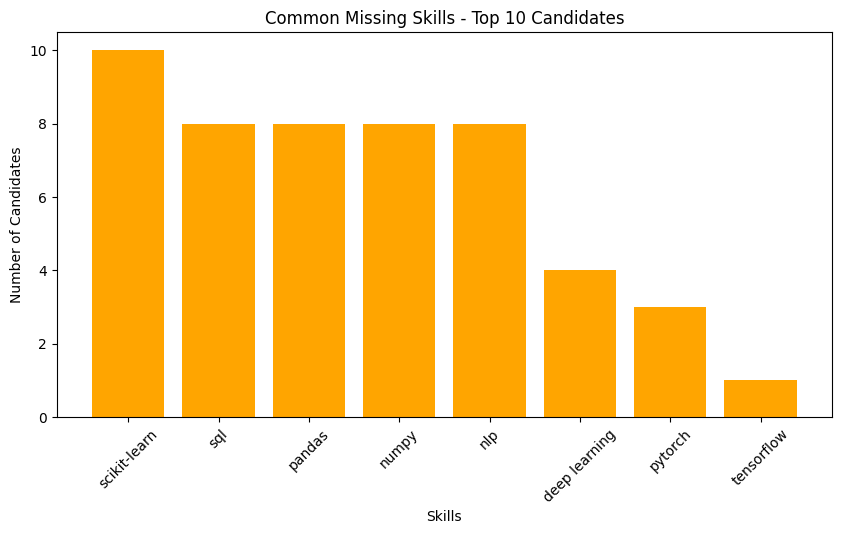

In [20]:
import matplotlib.pyplot as plt
from collections import Counter

skills_count = Counter()

for skills in top10["missing_skills"]:
    skills_count.update(skills)

skills_count = skills_count.most_common()

plt.figure(figsize=(10,5))
plt.bar(
    [x[0] for x in skills_count],
    [x[1] for x in skills_count],
    color="orange"
)

plt.title("Common Missing Skills - Top 10 Candidates")
plt.xlabel("Skills")
plt.ylabel("Number of Candidates")
plt.xticks(rotation=45)
plt.show()

In [21]:
final_results = df.sort_values(
    "match_score",
    ascending=False
).head(10)

display(
    final_results[
        [
            "resume_id",
            "category",
            "experience_years",
            "match_score",
            "missing_skills"
        ]
    ]
)

,resume_id,category,experience_years,match_score,missing_skills
2758,2761,Machine Learning Engineer,0.0,42.031332,"[sql, pandas, numpy, scikit-learn, pytorch, nlp]"
2487,2490,Data Science,2.0,41.172369,"[scikit-learn, pytorch]"
2693,2696,Machine Learning Engineer,0.0,39.479330,"[sql, pandas, numpy, scikit-learn, nlp]"
2689,2692,Machine Learning Engineer,0.0,39.375668,"[sql, pandas, numpy, scikit-learn, nlp]"
2814,2817,Data Scientist,0.0,38.575001,"[sql, pandas, numpy, scikit-learn, nlp]"
2756,2759,Machine Learning Engineer,0.0,37.228667,"[deep learning, sql, pandas, numpy, scikit-lea..."
2488,2491,Data Science,1.0,36.791399,"[scikit-learn, tensorflow, pytorch]"
2759,2762,Machine Learning Engineer,0.0,36.542094,"[deep learning, sql, pandas, numpy, scikit-lea..."
2686,2689,Machine Learning Engineer,0.0,36.405590,"[deep learning, sql, pandas, numpy, scikit-lea..."
2691,2694,Machine Learning Engineer,0.0,36.254614,"[deep learning, sql, pandas, numpy, scikit-lea..."
